In [1]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_excel("library_dataset.xlsx")
data

,Book ID,Book Title,Author,Genre,Publisher,ISBN,Year Published,Pages,Language,Price (₹),Available,Total Copies,Copies Issued,Location/Shelf,Rating (1-5)
0,LIB0001,The Great Gatsby,F. Scott Fitzgerald,Classic Fiction,HarperCollins,978-0-5506-5012-3,1885,329,Marathi,293.45,Yes,7,0,A-3,3.0
1,LIB0002,To Kill a Mockingbird,Harper Lee,Classic Fiction,Scholastic,978-9-1434-4257-8,1957,571,Hindi,1122.29,Yes,1,0,D-11,3.2
2,LIB0003,1984,George Orwell,Dystopian,Macmillan,978-5-2674-2519-6,1874,855,English,1146.15,No,1,1,E-4,4.9
3,LIB0004,Pride and Prejudice,Jane Austen,Romance,Cambridge University Press,978-1-5803-6925-9,1899,262,English,1241.08,Yes,5,0,B-4,3.5
4,LIB0005,The Catcher in the Rye,J.D. Salinger,Coming-of-Age,Bloomsbury,978-5-3664-7065-5,1903,666,English,1155.07,Yes,3,1,B-15,3.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,LIB0096,The Remains of the Day,Kazuo Ishiguro,Literary Fiction,Hachette,978-9-2391-1861-2,1890,221,English,598.97,No,7,7,E-15,3.5
96,LIB0097,Never Let Me Go,Kazuo Ishiguro,Literary Fiction,Macmillan,978-8-2864-6655-6,1878,700,Marathi,952.94,Yes,5,0,B-13,5.0
97,LIB0098,Atonement,Ian McEwan,Literary Fiction,Penguin Books,978-0-4349-5938-3,1885,643,English,691.40,No,1,1,D-6,2.8
98,LIB0099,The English Patient,Michael Ondaatje,Literary Fiction,Scholastic,978-3-9196-6802-1,1951,206,Hindi,180.92,Yes,2,1,E-14,3.9


In [4]:
data.head()

,Book ID,Book Title,Author,Genre,Publisher,ISBN,Year Published,Pages,Language,Price (₹),Available,Total Copies,Copies Issued,Location/Shelf,Rating (1-5)
0,LIB0001,The Great Gatsby,F. Scott Fitzgerald,Classic Fiction,HarperCollins,978-0-5506-5012-3,1885,329,Marathi,293.45,Yes,7,0,A-3,3.0
1,LIB0002,To Kill a Mockingbird,Harper Lee,Classic Fiction,Scholastic,978-9-1434-4257-8,1957,571,Hindi,1122.29,Yes,1,0,D-11,3.2
2,LIB0003,1984,George Orwell,Dystopian,Macmillan,978-5-2674-2519-6,1874,855,English,1146.15,No,1,1,E-4,4.9
3,LIB0004,Pride and Prejudice,Jane Austen,Romance,Cambridge University Press,978-1-5803-6925-9,1899,262,English,1241.08,Yes,5,0,B-4,3.5
4,LIB0005,The Catcher in the Rye,J.D. Salinger,Coming-of-Age,Bloomsbury,978-5-3664-7065-5,1903,666,English,1155.07,Yes,3,1,B-15,3.4


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Book ID         100 non-null    object 
 1   Book Title      100 non-null    object 
 2   Author          100 non-null    object 
 3   Genre           100 non-null    object 
 4   Publisher       100 non-null    object 
 5   ISBN            100 non-null    object 
 6   Year Published  100 non-null    int64  
 7   Pages           100 non-null    int64  
 8   Language        100 non-null    object 
 9   Price (₹)       100 non-null    float64
 10  Available       100 non-null    object 
 11  Total Copies    100 non-null    int64  
 12  Copies Issued   100 non-null    int64  
 13  Location/Shelf  100 non-null    object 
 14  Rating (1-5)    100 non-null    float64
dtypes: float64(2), int64(4), object(9)
memory usage: 11.8+ KB


In [6]:
data.isnull().sum()

Book ID           0
Book Title        0
Author            0
Genre             0
Publisher         0
ISBN              0
Year Published    0
Pages             0
Language          0
Price (₹)         0
Available         0
Total Copies      0
Copies Issued     0
Location/Shelf    0
Rating (1-5)      0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data=data.drop_duplicates()

In [9]:
data['Available Copies'] = data['Total Copies'] - data['Copies Issued']

In [11]:
data['Price_Category']=pd.cut(data['Price (₹)'],
                             bins=[0,100,500,1000],
                             labels=['Low','Mid','High'])

In [12]:
data['Genre'].value_counts().head(10)

Genre
Classic Fiction          20
Literary Fiction          9
Sci-Fi                    8
Self-Help                 7
Historical Fiction        6
Philosophical Fiction     6
Non-Fiction               4
Science                   4
Business                  4
Magical Realism           4
Name: count, dtype: int64

Text(0, 0.5, 'Count')

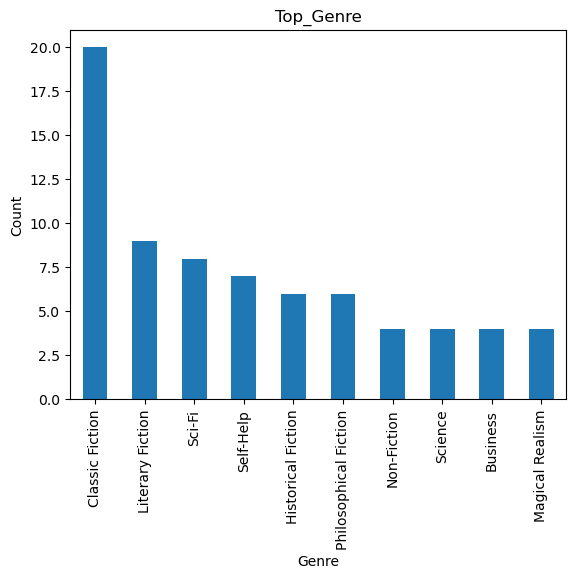

In [17]:
data['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top_Genre")
plt.xlabel("Genre")
plt.ylabel("Count")

Text(0, 0.5, '')

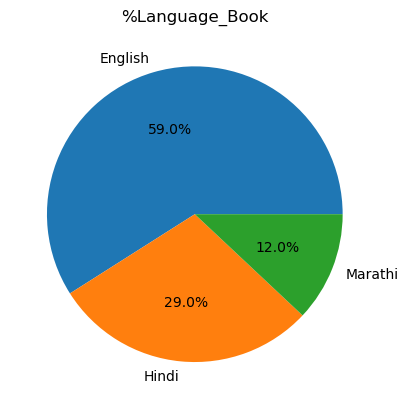

In [20]:
data['Language'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("%Language_Book")
plt.ylabel("")

<Axes: ylabel='count'>

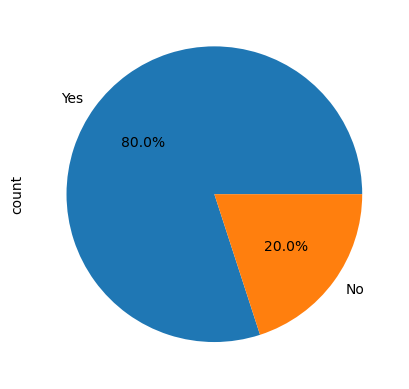

In [24]:
data['Available'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [27]:
top_price=data.sort_values(by='Price (₹)',ascending=True)
top_price=[['Book Titel','Price (₹)']]

In [30]:
genre_rating = data.groupby('Genre')['Rating (1-5)'].mean().sort_values(ascending=False)
print(genre_rating)

Genre
Satire                   5.000000
Fantasy                  4.900000
Dystopian                4.500000
Finance                  4.450000
Philosophy               4.400000
Thriller                 4.350000
Modernist                4.200000
Economics                4.100000
Adventure                4.000000
Crime                    4.000000
Mystery                  3.900000
Crime Thriller           3.900000
Sci-Fi                   3.850000
Philosophical Fiction    3.800000
Literary Fiction         3.777778
Science                  3.775000
Non-Fiction              3.775000
History                  3.650000
Classic Fiction          3.595000
Post-Apocalyptic         3.500000
Romance                  3.500000
Short Stories            3.450000
Coming-of-Age            3.400000
Business                 3.375000
Western                  3.200000
Memoir                   3.150000
Historical Fiction       3.150000
Magical Realism          3.125000
Self-Help                3.014286
Psycholo

<Axes: xlabel='Genre'>

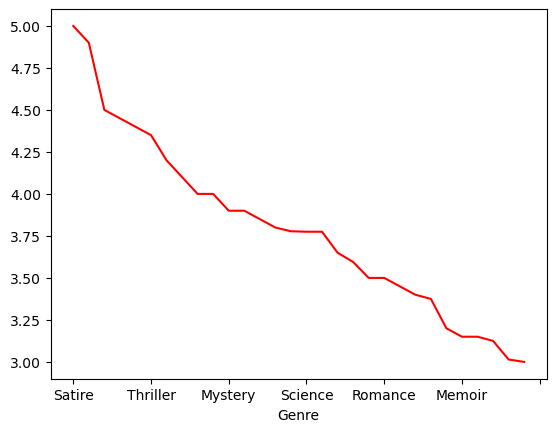

In [32]:
genre_rating.plot(kind='line',color='red')

(array([12.,  8., 15.,  4., 18.,  7., 15.,  7.,  5.,  9.]),
 array([2.5 , 2.75, 3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  ]),
 <BarContainer object of 10 artists>)

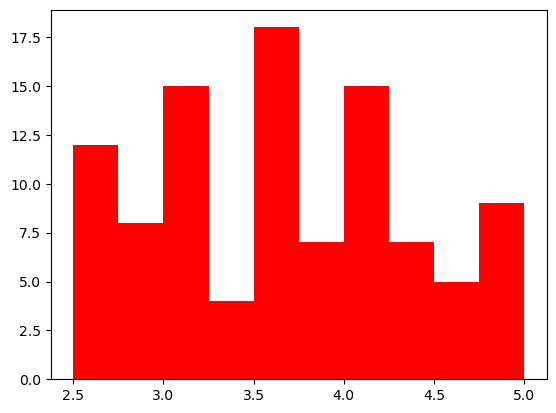

In [37]:
plt.hist(data['Rating (1-5)'],color='red')